# Tech Challenge 2 — Classificação de Qualidade de Vinhos

Observações:
1. Os limiares de decisão são calibrados no conjunto de **validação**.
2. Comparação de estratégias de balanceamento (Oversampling vs SMOTE vs `class_weight`) via **validação cruzada**.
3. Comparação de modelos (RF, LogReg, GBoost, XGBoost) via validação cruzada, com `average_precision` como métrica (mais adequada a dados desbalanceados que acurácia).
4. Ajuste de hiperparâmetros com `GridSearchCV`/`RandomizedSearchCV`.
5. O conjunto de **teste só é usado uma vez**, para validação final.


In [ ]:
# Importando as bibliotecas essenciais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 1. Carregando os dados
df = pd.read_csv('WineQT.csv')

# Visualizando as primeiras linhas
display(df.head())

# Criando a variável alvo binária (Target)
df['target'] = np.where(df['quality'] >= 7, 1, 0)

print("Transformação concluída! Variável 'target' criada.")
print(f"\nDistribuição do target:\n{df['target'].value_counts()}")


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


Transformação concluída! Variável 'target' criada.

Distribuição do target:
target
0    984
1    159
Name: count, dtype: int64


## 1. Análise Exploratória

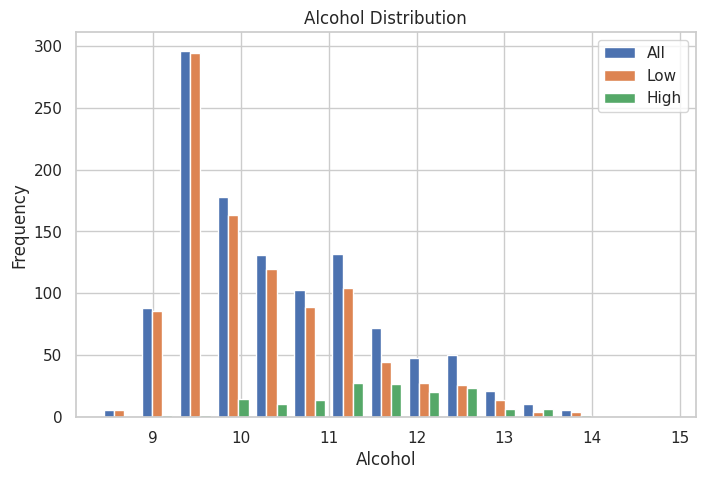

In [ ]:
df_high = df[df['target'] == 1]
df_low  = df[df['target'] == 0]

plt.figure(figsize=(8, 5))
plt.hist([df['alcohol'], df_low['alcohol'], df_high['alcohol']],
         label=['All', 'Low', 'High'], bins=15)
plt.title('Alcohol Distribution')
plt.xlabel('Alcohol')
plt.ylabel('Frequency')
plt.legend()
plt.show()


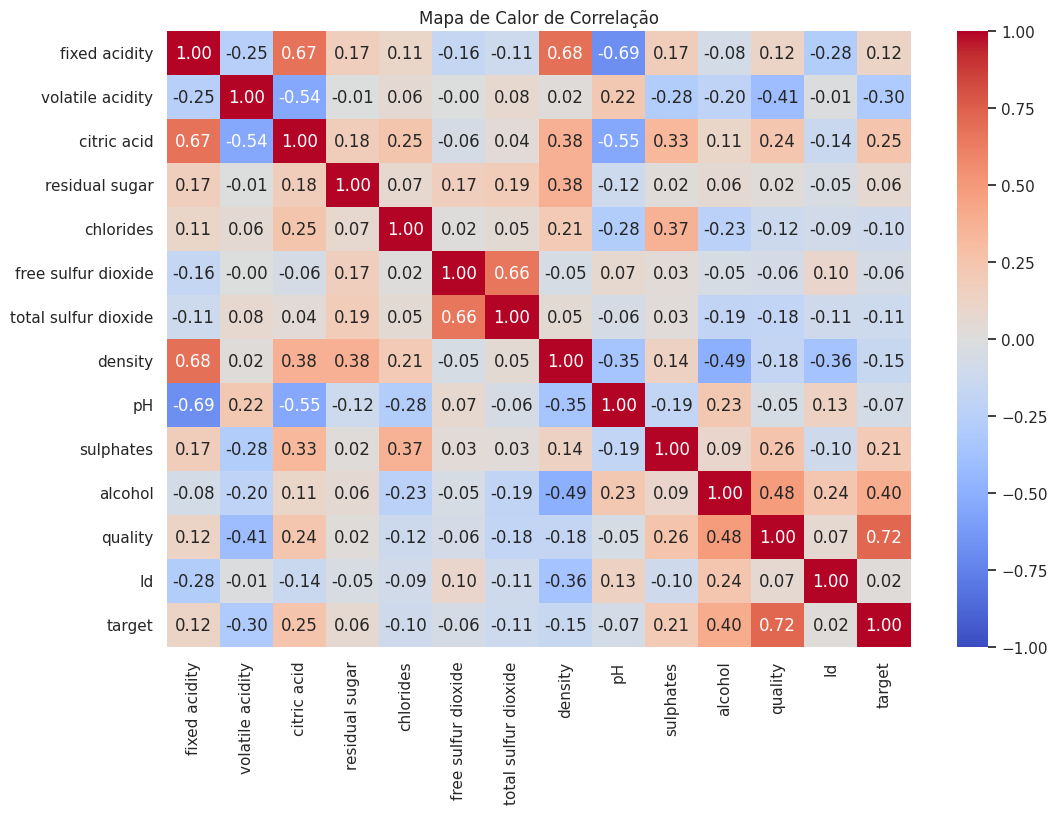

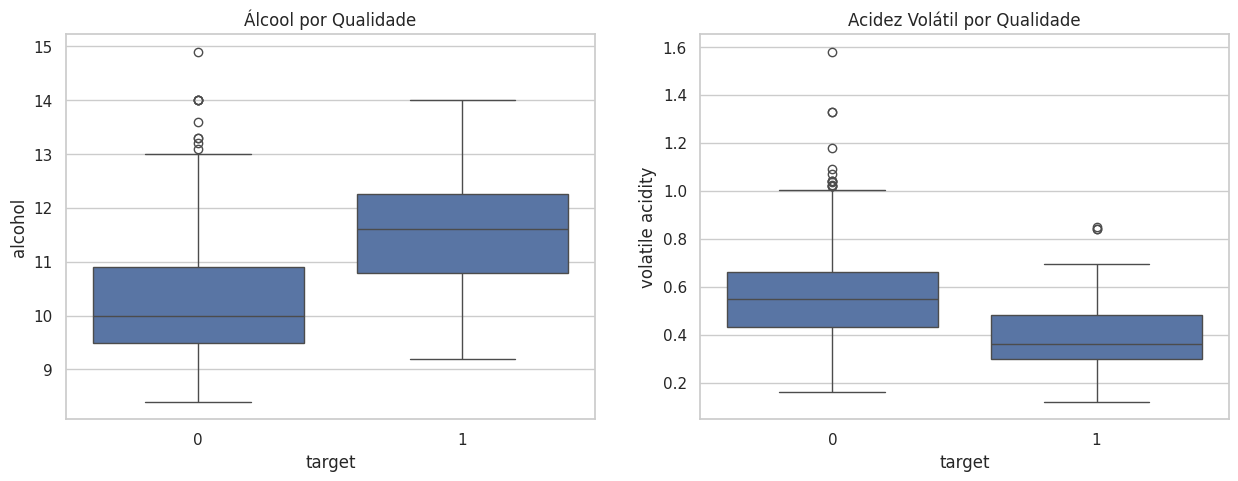

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, center=0)
plt.title('Mapa de Calor de Correlação')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(x='target', y='alcohol', data=df, ax=axes[0])
axes[0].set_title('Álcool por Qualidade')
sns.boxplot(x='target', y='volatile acidity', data=df, ax=axes[1])
axes[1].set_title('Acidez Volátil por Qualidade')
plt.show()


### 1.1 Justificativa das correlações observadas

Olhando a correlação de cada variável com `quality` (e algumas relações entre variáveis
explicativas), dá pra explicar o *porquê* fisico-químico de cada uma, não só reportar o número:

- **Álcool (+0.48, a mais forte)** — teor alcoólico mais alto normalmente vem de uvas com mais
  açúcar na colheita (melhor maturação) e de uma fermentação mais completa. Isso tende a se
  traduzir em vinhos mais bem avaliados sensorialmente, o que explica a correlação positiva forte.
- **Acidez volátil (-0.41, a mais forte negativa)** — acidez volátil alta é, na prática, um
  indicador de contaminação por bactérias acéticas durante a fermentação (o "gosto de vinagre").
  Faz sentido que quanto mais alta, pior a nota dos especialistas.
- **Sulfatos (+0.26) e ácido cítrico (+0.24)** — sulfatos atuam como conservante/antioxidante
  (ligados ao SO2) e ácido cítrico contribui para frescor e equilíbrio de sabor; ambos associados
  a vinhos mais "estáveis" e bem avaliados.
- **Densidade (-0.18) e dióxido de enxofre total (-0.18)** — densidade mais alta indica mais
  açúcar residual não convertido (fermentação menos completa); SO2 total muito alto pode indicar
  correção excessiva/vinho menos "limpo" aromaticamente. Ambas fazem sentido como sinal negativo.
- **Densidade x Álcool (-0.49, entre variáveis explicativas)** — não é coincidência: o processo
  de fermentação converte açúcar (mais denso) em álcool e CO₂ (menos denso). Essa correlação é
  esperada pela própria química da fermentação, não é uma descoberta sobre qualidade.
- **Dióxido de enxofre livre x total (+0.66)** — correlação estrutural: SO2 livre é um
  subconjunto do SO2 total por definição, então essa correlação alta não traz informação nova.
- **Ácido cítrico x acidez volátil (-0.54)** — os dois competem quimicamente durante a
  fermentação; mais ácido cítrico geralmente acompanha menor acidez volátil, sinal de fermentação
  mais controlada.

**Implicação prática**: como densidade e SO2 livre/total carregam bastante redundância entre si
(e com álcool), multicolinearidade é esperada. Isso pesa mais para a Regressão Logística
(coeficientes ficam instáveis) do que para os modelos baseados em árvore (RF, GBoost, XGBoost),
que lidam bem com variáveis redundantes.

## 2. Verificação de dados faltantes e outliers

In [ ]:
# Verificação de dados faltantes
print("Valores nulos por coluna:")
print(df.isnull().sum())
print(f"\nTotal de linhas com pelo menos um valor faltante: {df.isnull().any(axis=1).sum()}")


Valores nulos por coluna:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
target                  0
dtype: int64

Total de linhas com pelo menos um valor faltante: 0


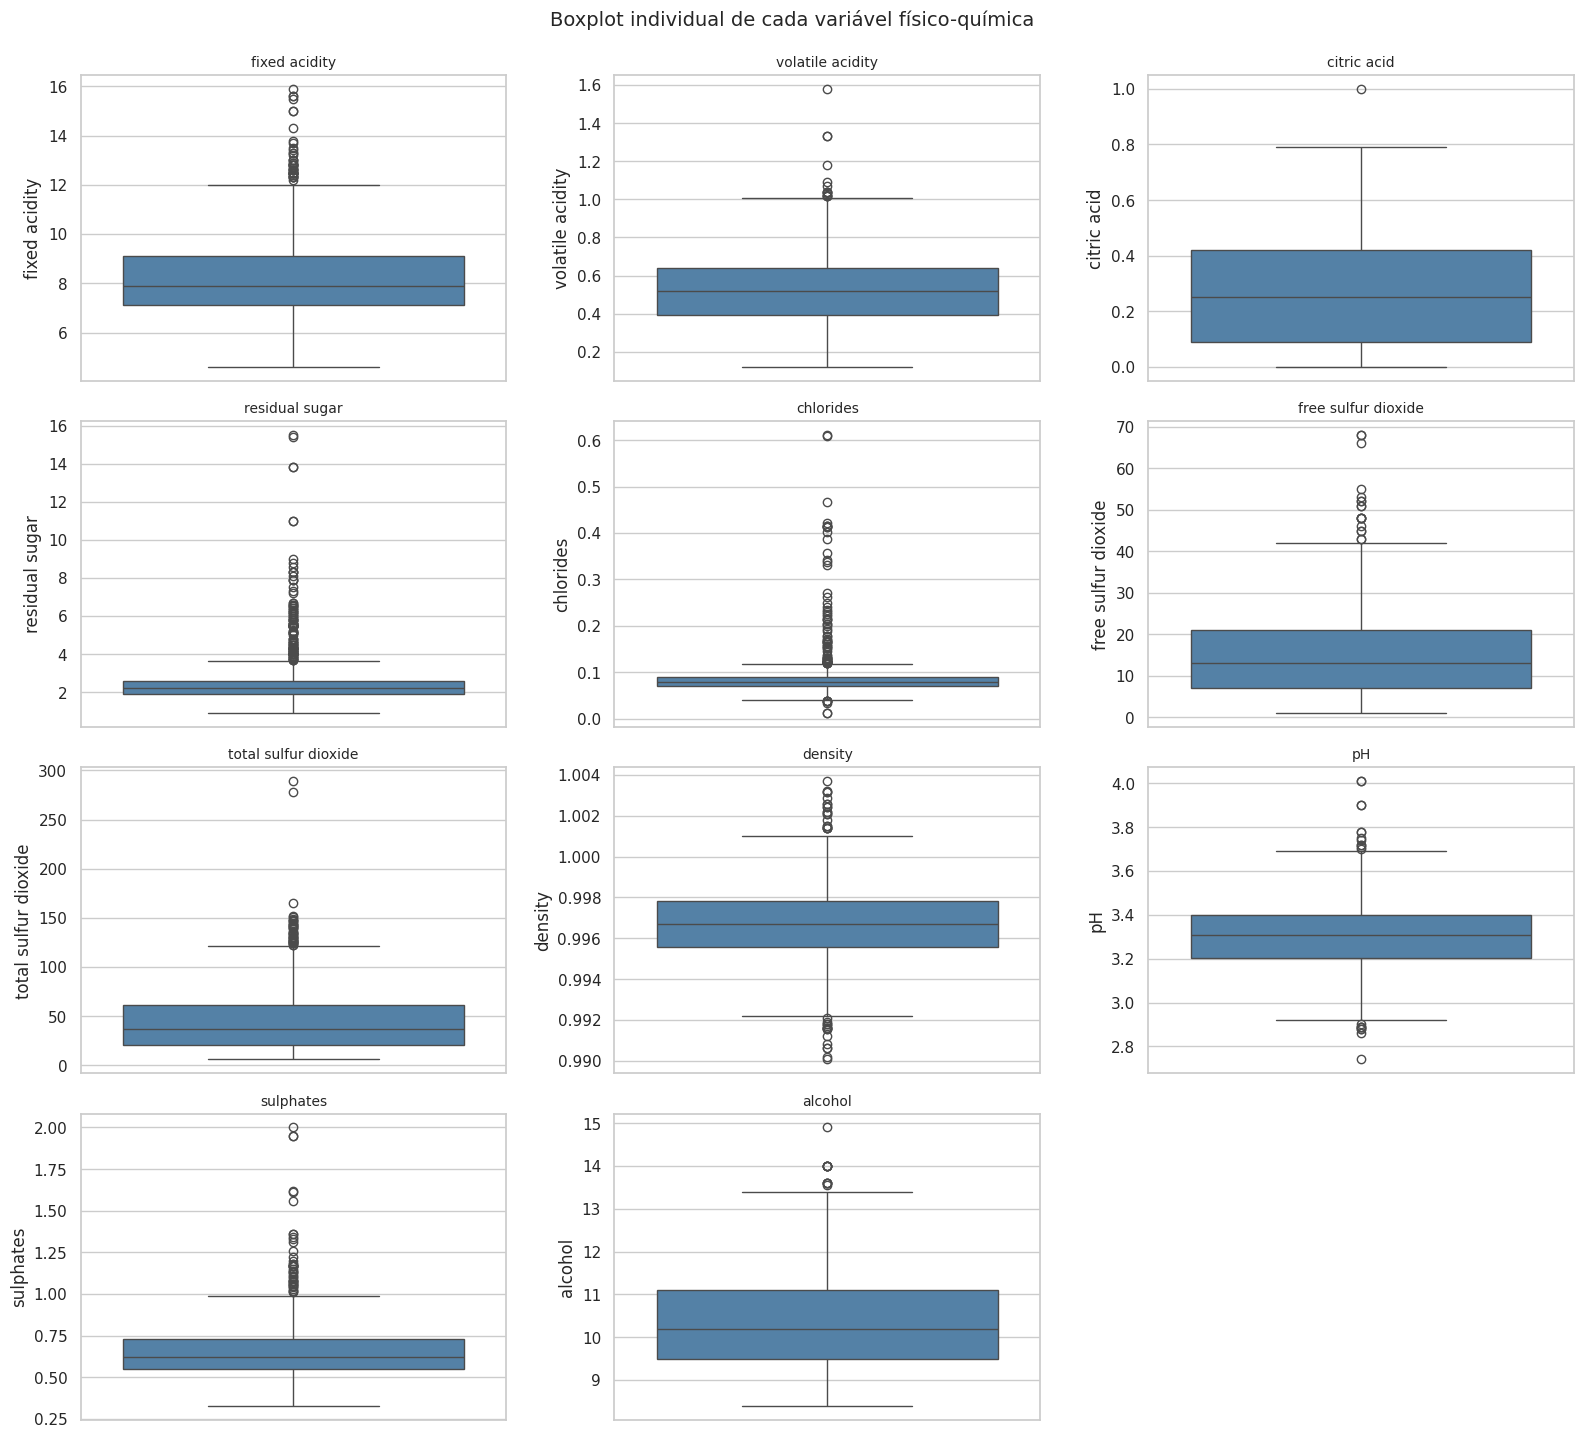

Quantidade de outliers por variável (regra IQR):
residual sugar          110
chlorides                77
fixed acidity            44
sulphates                43
total sulfur dioxide     40
density                  36
pH                       20
free sulfur dioxide      18
volatile acidity         14
alcohol                  12
citric acid               1
dtype: int64

Total de linhas do dataset: 1143


In [ ]:
# Detecção de outliers por variável (regra do IQR: 1.5x o intervalo interquartil)
colunas_numericas = [c for c in df.columns if c not in ('Id', 'quality', 'target')]

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()
for i, col in enumerate(colunas_numericas):
    sns.boxplot(y=df[col], ax=axes[i], color='steelblue')
    axes[i].set_title(col, fontsize=10)
for j in range(len(colunas_numericas), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.suptitle('Boxplot individual de cada variável físico-química', y=1.02, fontsize=14)
plt.show()

def contar_outliers_iqr(serie):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    limite_inf, limite_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((serie < limite_inf) | (serie > limite_sup)).sum()

outliers_por_coluna = pd.Series(
    {col: contar_outliers_iqr(df[col]) for col in colunas_numericas}
).sort_values(ascending=False)

print("Quantidade de outliers por variável (regra IQR):")
print(outliers_por_coluna)
print(f"\nTotal de linhas do dataset: {len(df)}")


**Considerações sobre os outliers**

Variáveis como `residual sugar`, `chlorides`, `sulphates` e `total sulfur dioxide` concentram a
maior parte dos outliers, o que é esperado em dados físico-químicos de vinho, onde certos lotes
(ex.: vinhos mais doces ou com correção de acidez mais agressiva) realmente têm valores extremos
por características legítimas do processo, não por erro de medição.

**Decisão adotada**: manter os outliers sem remoção ou *capping*:

1. Não há evidência de erro de digitação/sensor (nenhum valor negativo, nenhum fora de faixa
   fisicamente impossível), parecem variações reais entre lotes.
2. Random Forest, Gradient Boosting e XGBoost são mais robustos a outliers por natureza (decisões por
   corte em vez de distância). Já a Regressão Logística é mais sensível, mas isso será mitigado pelo
   `StandardScaler` no pipeline, apenas tendo atenção ao interpretar os
   coeficientes desse modelo especificamente.

## 3. Feature engineering

Criação de variáveis derivadas com justificativa físico-química, para avaliar se elas
agregam informação além das variáveis originais. Elas entram no `X` junto com as demais e suas
importâncias serão avaliadas mais adiante (seção 11).

In [ ]:
# Acidez total: soma da acidez fixa e volátil — captura o total de ácidos "pesados" do vinho
df['acidez_total'] = df['fixed acidity'] + df['volatile acidity']

# Proporção de SO2 livre em relação ao total — indicador de quanto do conservante
# ainda está "ativo" (livre) versus ligado quimicamente; conceito comum em enologia
df['razao_so2_livre'] = df['free sulfur dioxide'] / df['total sulfur dioxide'].replace(0, np.nan)
df['razao_so2_livre'] = df['razao_so2_livre'].fillna(0)

# Álcool por unidade de densidade — combina os dois indicadores de "quão completa"
# foi a fermentação em uma única variável
df['alcool_por_densidade'] = df['alcohol'] / df['density']

print("Novas variáveis criadas: acidez_total, razao_so2_livre, alcool_por_densidade")
display(df[['acidez_total', 'razao_so2_livre', 'alcool_por_densidade']].describe())


Novas variáveis criadas: acidez_total, razao_so2_livre, alcool_por_densidade


,acidez_total,razao_so2_livre,alcool_por_densidade
count,1143.000000,1143.000000,1143.000000
mean,8.842450,0.380418,10.477443
std,1.711413,0.154112,1.096987
min,5.120000,0.022727,8.393285
25%,7.690000,0.257473,9.536716
50%,8.460000,0.375000,10.208780
75%,9.660000,0.478261,11.160139
max,16.285000,0.857143,14.935846


## 4. Divisão treino / validação / teste

Realizada divisão 70-15-15%. O **conjunto de validação
será de fato utilizado** para comparar estratégias, ajustar hiperparâmetros e calibrar limiares.
O **conjunto de teste não é utilizado até a última célula da seção 6**.

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(['quality', 'Id', 'target'], axis=1)
y = df['target']

# Step 1: 85% treino+validação / 15% teste
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=37, stratify=y
)

# Step 2: dentro do treino+validação, separa 15% (do total) para validação
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=(0.15 / 0.85), random_state=37, stratify=y_train_val
)

print(f"Dados de treino:     {X_train.shape[0]} amostras")
print(f"Dados de validação:  {X_val.shape[0]} amostras")
print(f"Dados de teste:      {X_test.shape[0]} amostras")


Dados de treino:     799 amostras
Dados de validação:  172 amostras
Dados de teste:      172 amostras


## 5. Baseline (Modelo "bobo")

Comparação antes do modelo real, para demonstrar o quanto a acurácia
isolada pode enganar neste dataset desbalanceado.

Relatório do Modelo 'Bobo' (Sempre chuta 0):
              precision    recall  f1-score   support

           0       0.86      1.00      0.93       148
           1       0.00      0.00      0.00        24

    accuracy                           0.86       172
   macro avg       0.43      0.50      0.46       172
weighted avg       0.74      0.86      0.80       172



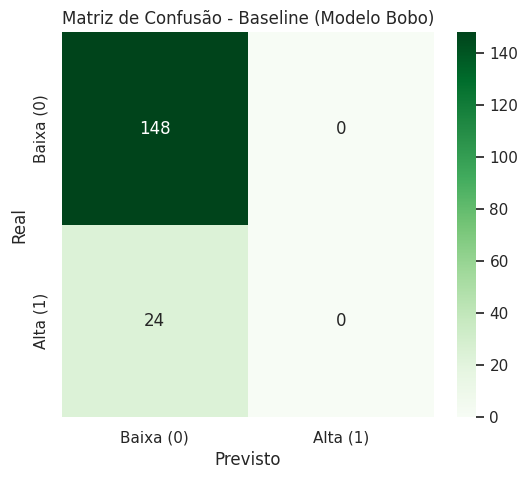

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

modelo_bobo = DummyClassifier(strategy='most_frequent')
modelo_bobo.fit(X_train, y_train)
y_pred_bobo = modelo_bobo.predict(X_test)

print("Relatório do Modelo 'Bobo' (Sempre chuta 0):")
print(classification_report(y_test, y_pred_bobo, zero_division=0))

cm_bobo = confusion_matrix(y_test, y_pred_bobo)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_bobo, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Baixa (0)', 'Alta (1)'], yticklabels=['Baixa (0)', 'Alta (1)'])
plt.xlabel('Previsto'); plt.ylabel('Real')
plt.title('Matriz de Confusão - Baseline (Modelo Bobo)')
plt.show()


## 6. Estratégia de balanceamento

Comparação de três estratégias
com **validação cruzada estratificada dentro do treino**.
A métrica usada é `average_precision` (AUC-PR), mais informativa que acurácia quando a classe
positiva é rara.

In [ ]:
# #!só mencionar que escolhemos o random over sampler

# from sklearn.model_selection import StratifiedKFold, cross_val_score
# from sklearn.ensemble import RandomForestClassifier
# from imblearn.over_sampling import RandomOverSampler, SMOTE
# from imblearn.pipeline import Pipeline as ImbPipeline

# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=37)

# estrategias = {
#     'RandomOverSampler': ImbPipeline([
#         ('sampler', RandomOverSampler(random_state=37)),
#         ('modelo', RandomForestClassifier(n_estimators=100, random_state=37))
#     ]),
#     'SMOTE': ImbPipeline([
#         ('sampler', SMOTE(random_state=37)),
#         ('modelo', RandomForestClassifier(n_estimators=100, random_state=37))
#     ]),
#     'class_weight_balanced': RandomForestClassifier(
#         n_estimators=100, random_state=37, class_weight='balanced'
#     ),
# }

# resultados_estrategias = {}
# for nome, pipeline in estrategias.items():
#     scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='average_precision')
#     resultados_estrategias[nome] = scores
#     print(f"{nome:25s} AUC-PR médio: {scores.mean():.3f}  (+/- {scores.std():.3f})")

# melhor_estrategia = max(resultados_estrategias, key=lambda k: resultados_estrategias[k].mean())
# print(f"\nMelhor estratégia (maior AUC-PR médio): {melhor_estrategia}")


## 7. Comparação de Modelos via Validação Cruzada

Agora comparamos famílias de modelos usando a estratégia de balanceamento vencedora da etapa
anterior, sempre com CV dentro do treino — o teste continua intocado.

In [ ]:
#!plotar os resultados de desempenho de cada modelo

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

# Reaplicamos a estratégia vencedora dentro de cada pipeline de CV,
# para não vazar informação do resampling entre os folds.
def montar_pipeline(modelo_base, usa_scaler=False):
    passos = []
    # Aplicar direto a estratégia de balanceamento: RandomOverSampler
    passos.append(('sampler', RandomOverSampler(random_state=37)))
    if usa_scaler:
        passos.append(('scaler', StandardScaler()))
    passos.append(('modelo', modelo_base))
    return ImbPipeline(passos) if any(p[0] == 'sampler' for p in passos) else Pipeline(passos)

# 'melhor_estrategia' foi 'RandomOverSampler', então class_weight_kw deve ser vazio.
class_weight_kw = {}

modelos_candidatos = {
    'RandomForest': montar_pipeline(
        RandomForestClassifier(n_estimators=100, random_state=37, **class_weight_kw)
    ),
    'LogisticRegression': montar_pipeline(
        LogisticRegression(random_state=37, max_iter=1000, **class_weight_kw), usa_scaler=True
    ),
    'GradientBoosting': montar_pipeline(
        GradientBoostingClassifier(random_state=37)
    ),
    'XGBoost': montar_pipeline(
        XGBClassifier(random_state=37, eval_metric='logloss',
                       # 'melhor_estrategia' foi 'RandomOverSampler', então scale_pos_weight é 1.
                       scale_pos_weight=1)
    ),
}

print("Comparação de modelos (AUC-PR médio via CV, 5 folds):\n")
resultados_modelos = {}
for nome, pipeline in modelos_candidatos.items():
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='average_precision')
    resultados_modelos[nome] = scores
    print(f"{nome:20s} {scores.mean():.3f}  (+/- {scores.std():.3f})")

melhor_modelo_nome = max(resultados_modelos, key=lambda k: resultados_modelos[k].mean())
print(f"\nMelhor modelo (maior AUC-PR médio): {melhor_modelo_nome}")

Comparação de modelos (AUC-PR médio via CV, 5 folds):

RandomForest         0.677  (+/- 0.037)
LogisticRegression   0.520  (+/- 0.055)
GradientBoosting     0.592  (+/- 0.074)
XGBoost              0.604  (+/- 0.054)

Melhor modelo (maior AUC-PR médio): RandomForest


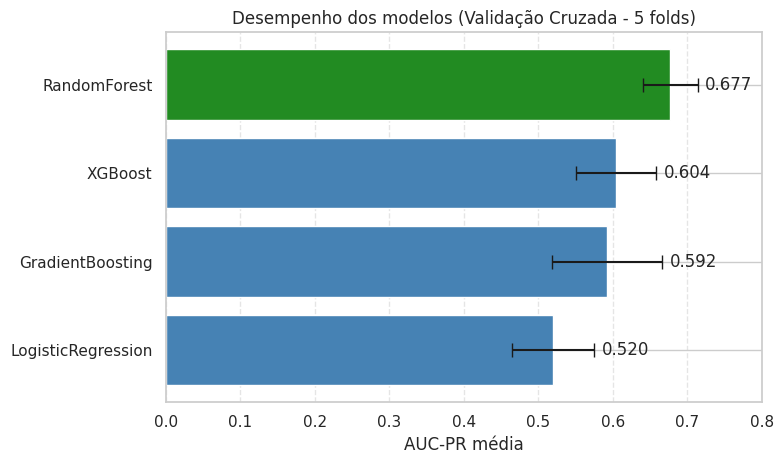

In [ ]:
import matplotlib.pyplot as plt

modelos = ["RandomForest", "XGBoost", "GradientBoosting", "LogisticRegression"]
media = [0.677, 0.604, 0.592, 0.520]
desvio = [0.037, 0.054, 0.074, 0.055]

plt.figure(figsize=(8,4.8))

cores = ["forestgreen", "steelblue", "steelblue", "steelblue"]

plt.barh(modelos, media, xerr=desvio, color=cores, capsize=5)

plt.xlabel("AUC-PR média")
plt.title("Desempenho dos modelos (Validação Cruzada - 5 folds)")
plt.xlim(0, 0.8)
plt.grid(axis="x", linestyle="--", alpha=0.5)

for i, v in enumerate(media):
    # Ajustando a posição do texto para ficar à direita da barra de erro
    plt.text(v + desvio[i] + 0.01, i, f"{v:.3f}", va="center")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 8. Ajuste de Hiperparâmetros (GridSearchCV)

Ajustamos hiperparâmetros só do modelo vencedor da etapa anterior, usando a mesma
validação cruzada e a mesma métrica (`average_precision`). Isso substitui os valores
"escolhidos manualmente" (ex.: `n_estimators=300, learning_rate=0.05` do XGBoost original)
por valores justificados por busca sistemática.

Os hiperparâmetros são configurações que não são aprendidas a partir dos dados durante o treinamento, mas que são definidas antes do processo de treinamento começar. Exemplos incluem o número de árvores em uma Random Forest (`n_estimators`) ou a profundidade máxima das árvores (`max_depth`).

Para definir esses valores de forma sistemática e encontrar a melhor combinação, foi utilizado o `GridSearchCV`.

### Como funciona o GridSearchCV:

1.  **Define-se um 'grid' de parâmetros**: Você especifica uma lista de possíveis valores para cada hiperparâmetro que deseja otimizar (por exemplo, `n_estimators` pode ser testado com valores como 100, 200, 300).
2.  **Validação Cruzada**: O `GridSearchCV` treina o modelo para cada combinação possível de hiperparâmetros nesse 'grid', avaliando o desempenho de cada combinação usando validação cruzada (no caso, `StratifiedKFold` com 5 folds, que divide os dados de treino em 5 partes para treinar e validar internamente).
3.  **Métrica de Avaliação**: Para cada combinação, o desempenho é medido usando uma métrica específica. Neste notebook, foi utilizada a métrica `average_precision` (AUC-PR), que é mais adequada para datasets desbalanceados como o nosso, onde a classe positiva é rara.
4.  **Seleção da Melhor Combinação**: Após testar todas as combinações, o `GridSearchCV` seleciona o conjunto de hiperparâmetros que resultou no melhor `average_precision` médio na validação cruzada.

No nosso caso, o `RandomForestClassifier` foi o modelo vencedor da etapa de comparação e, ao aplicar o `GridSearchCV` no conjunto de treino, os melhores parâmetros encontrados foram:

*   `modelo__max_depth`: 8
*   `modelo__min_samples_leaf`: 1
*   `modelo__n_estimators`: 200

Isso significa que, dentre as opções testadas, essa combinação específica de hiperparâmetros forneceu o melhor equilíbrio entre precisão e recall para a identificação de vinhos de alta qualidade, de acordo com a métrica `average_precision`.

Os hiperparâmetros testados para o **RandomForestClassifier** durante a busca `GridSearchCV` foram:

*   `modelo__n_estimators`: Número de árvores na floresta. Os valores testados foram: `[100, 200, 300]`.
*   `modelo__max_depth`: Profundidade máxima da árvore. Os valores testados foram: `[None, 8, 12]` (onde `None` significa profundidade ilimitada).
*   `modelo__min_samples_leaf`: Número mínimo de amostras necessárias para estar em um nó folha. Os valores testados foram: `[1, 2, 4]`.

O `GridSearchCV` explorou todas as combinações desses valores para encontrar a melhor performance, e os parâmetros vencedores foram `max_depth: 8`, `min_samples_leaf: 1` e `n_estimators: 200`.

In [ ]:
from sklearn.model_selection import GridSearchCV

grades = {
    'RandomForest': {
        'modelo__n_estimators': [100, 200, 300],
        'modelo__max_depth': [None, 8, 12],
        'modelo__min_samples_leaf': [1, 2, 4],
    },
    'GradientBoosting': {
        'modelo__n_estimators': [100, 200, 300],
        'modelo__learning_rate': [0.03, 0.05, 0.1],
        'modelo__max_depth': [2, 3, 4],
    },
    'XGBoost': {
        'modelo__n_estimators': [150, 300, 450],
        'modelo__learning_rate': [0.03, 0.05, 0.1],
        'modelo__max_depth': [3, 4, 6],
    },
    'LogisticRegression': {
        'modelo__C': [0.01, 0.1, 1, 10],
    },
}

pipeline_vencedor = modelos_candidatos[melhor_modelo_nome]
grid = grades.get(melhor_modelo_nome, {})

if grid:
    busca = GridSearchCV(pipeline_vencedor, grid, cv=cv, scoring='average_precision', n_jobs=-1)
    busca.fit(X_train, y_train)
    print(f"Melhores parâmetros para {melhor_modelo_nome}:")
    print(busca.best_params_)
    print(f"Melhor AUC-PR (CV): {busca.best_score_:.3f}")
    modelo_final = busca.best_estimator_
else:
    pipeline_vencedor.fit(X_train, y_train)
    modelo_final = pipeline_vencedor

print("\nModelo final treinado com todo o conjunto de treino.")


Melhores parâmetros para RandomForest:
{'modelo__max_depth': 8, 'modelo__min_samples_leaf': 1, 'modelo__n_estimators': 200}
Melhor AUC-PR (CV): 0.692

Modelo final treinado com todo o conjunto de treino.


## 9. Calibração de Limiar — usando o conjunto de VALIDAÇÃO

Limiares de decisão (ex.: "alta qualidade" vs.
"potencialmente alta qualidade") difinidos pela observação da curva Precision-Recall
**no conjunto de validação**.

*O conjunto de teste só é utilizado na seção 8, uma única vez.

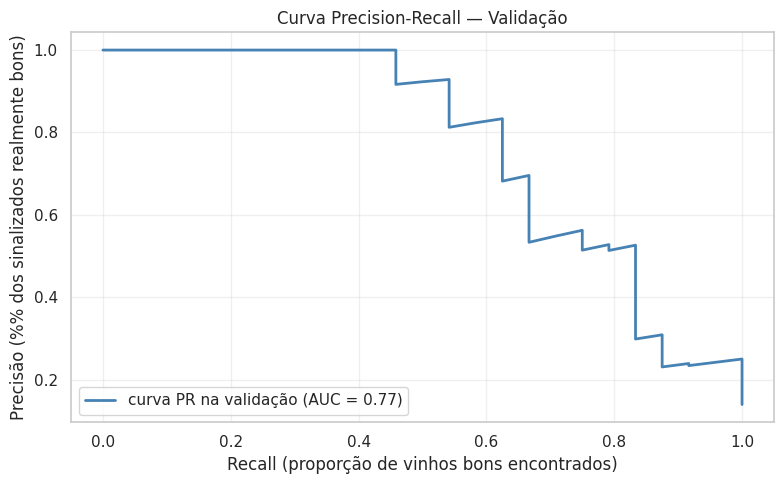

AUC-PR (validação): 0.767


In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

y_probs_val = modelo_final.predict_proba(X_val)[:, 1]

precision_val, recall_val, thresholds_val = precision_recall_curve(y_val, y_probs_val)
auc_pr_val = average_precision_score(y_val, y_probs_val)

plt.figure(figsize=(8, 5))
plt.plot(recall_val, precision_val, color='steelblue', lw=2,
         label=f'curva PR na validação (AUC = {auc_pr_val:.2f})')
plt.xlabel('Recall (proporção de vinhos bons encontrados)')
plt.ylabel('Precisão (%% dos sinalizados realmente bons)')
plt.title('Curva Precision-Recall — Validação')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC-PR (validação): {auc_pr_val:.3f}")


In [ ]:
# Escolha dos limiares com base na validação.
# Critério: 'certificação' = maior precisão possível mantendo recall >= 0.30
#           'triagem'       = maior recall possível mantendo precisão >= 0.50
# Ajuste os valores de recall/precisão mínimos conforme a necessidade do negócio.

def escolher_limiar(precision, recall, thresholds, min_recall=None, min_precision=None):
    candidatos = []
    for p, r, t in zip(precision[:-1], recall[:-1], thresholds):
        if min_recall is not None and r < min_recall:
            continue
        if min_precision is not None and p < min_precision:
            continue
        candidatos.append((t, p, r))
    if not candidatos:
        return None
    if min_precision is not None:
        return max(candidatos, key=lambda c: c[2])   # maior recall dado o piso de precisão
    return max(candidatos, key=lambda c: c[1])        # maior precisão dado o piso de recall

limiar_certificacao = escolher_limiar(precision_val, recall_val, thresholds_val, min_recall=0.30)
limiar_triagem       = escolher_limiar(precision_val, recall_val, thresholds_val, min_precision=0.50)

print(f"Limiar de certificação (alta precisão): {limiar_certificacao}")
print(f"Limiar de triagem (alto recall):        {limiar_triagem}")

limiar_alta = limiar_certificacao[0] if limiar_certificacao else 0.725
limiar_pot  = limiar_triagem[0] if limiar_triagem else 0.47

print(f"\nLimiares definidos a partir da VALIDAÇÃO:")
print(f"  alta qualidade (certificação): {limiar_alta:.3f}")
print(f"  potencialmente alta qualidade (triagem): {limiar_pot:.3f}")


Limiar de certificação (alta precisão): (np.float64(0.8528892498331244), np.float64(1.0), np.float64(0.4583333333333333))
Limiar de triagem (alto recall):        (np.float64(0.4747992903642483), np.float64(0.5), np.float64(0.8333333333333334))

Limiares definidos a partir da VALIDAÇÃO:
  alta qualidade (certificação): 0.853
  potencialmente alta qualidade (triagem): 0.475


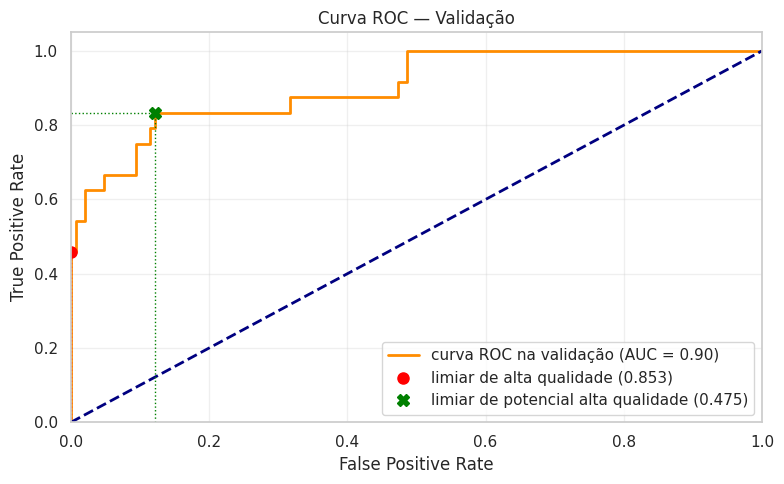

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score

fpr_val, tpr_val, thresholds_val = roc_curve(y_val, y_probs_val)
auc_roc_val = roc_auc_score(y_val, y_probs_val)

plt.figure(figsize=(8, 5))
plt.plot(fpr_val, tpr_val, color='darkorange', lw=2,
         label=f'curva ROC na validação (AUC = {auc_roc_val:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Adicionar o limiar de alta precisão (limiar_alta)
if 'limiar_alta' in globals() and limiar_alta is not None:
    # Encontrar o ponto na curva ROC mais próximo do limiar_alta
    idx_alta = np.argmin(np.abs(thresholds_val - limiar_alta))
    fpr_at_threshold_alta = fpr_val[idx_alta]
    tpr_at_threshold_alta = tpr_val[idx_alta]

    plt.plot(fpr_at_threshold_alta, tpr_at_threshold_alta, 'o', color='red', markersize=8,
             label=f'limiar de alta qualidade ({limiar_alta:.3f})')
    plt.plot([fpr_at_threshold_alta, fpr_at_threshold_alta], [0, tpr_at_threshold_alta], color='red', linestyle=':', lw=1)
    plt.plot([0, fpr_at_threshold_alta], [tpr_at_threshold_alta, tpr_at_threshold_alta], color='red', linestyle=':', lw=1)

# Adicionar o limiar de potencial alta precisão (limiar_pot)
if 'limiar_pot' in globals() and limiar_pot is not None:
    # Encontrar o ponto na curva ROC mais próximo do limiar_pot
    idx_pot = np.argmin(np.abs(thresholds_val - limiar_pot))
    fpr_at_threshold_pot = fpr_val[idx_pot]
    tpr_at_threshold_pot = tpr_val[idx_pot]

    plt.plot(fpr_at_threshold_pot, tpr_at_threshold_pot, 'X', color='green', markersize=8,
             label=f'limiar de potencial alta qualidade ({limiar_pot:.3f})')
    plt.plot([fpr_at_threshold_pot, fpr_at_threshold_pot], [0, tpr_at_threshold_pot], color='green', linestyle=':', lw=1)
    plt.plot([0, fpr_at_threshold_pot], [tpr_at_threshold_pot, tpr_at_threshold_pot], color='green', linestyle=':', lw=1)


plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC — Validação')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Avaliação Final — ÚNICO uso do conjunto de Teste

Agora, e só agora, aplicamos o modelo final e os limiares (definidos na validação) ao
conjunto de teste. Este é o número que vai para o relatório.

Relatório de Classificação — Teste (modelo: RandomForest, limiar: 0.853):
              precision    recall  f1-score   support

           0       0.91      0.99      0.95       148
           1       0.91      0.42      0.57        24

    accuracy                           0.91       172
   macro avg       0.91      0.70      0.76       172
weighted avg       0.91      0.91      0.90       172



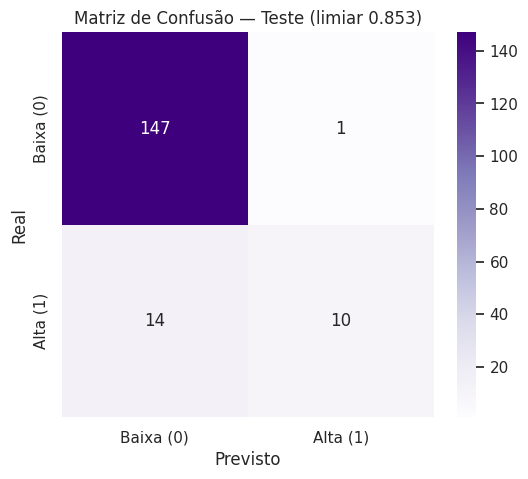


AUC-PR no teste (número final, sem re-calibração): 0.768


In [ ]:
y_probs_rf = modelo_final.predict_proba(X_test)[:, 1]   # nome mantido por compatibilidade com o restante do notebook
y_pred_final = (y_probs_rf >= limiar_alta).astype(int)

print(f"Relatório de Classificação — Teste (modelo: {melhor_modelo_nome}, limiar: {limiar_alta:.3f}):")
print(classification_report(y_test, y_pred_final))

cm_final = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Baixa (0)', 'Alta (1)'], yticklabels=['Baixa (0)', 'Alta (1)'])
plt.xlabel('Previsto'); plt.ylabel('Real')
plt.title(f'Matriz de Confusão — Teste (limiar {limiar_alta:.3f})')
plt.show()

precision_test, recall_test, _ = precision_recall_curve(y_test, y_probs_rf)
auc_pr_test = average_precision_score(y_test, y_probs_rf)
print(f"\nAUC-PR no teste (número final, sem re-calibração): {auc_pr_test:.3f}")


Relatório de Classificação — Teste (modelo: RandomForest, limiar: 0.475):
              precision    recall  f1-score   support

           0       0.96      0.91      0.93       148
           1       0.56      0.75      0.64        24

    accuracy                           0.88       172
   macro avg       0.76      0.83      0.79       172
weighted avg       0.90      0.88      0.89       172



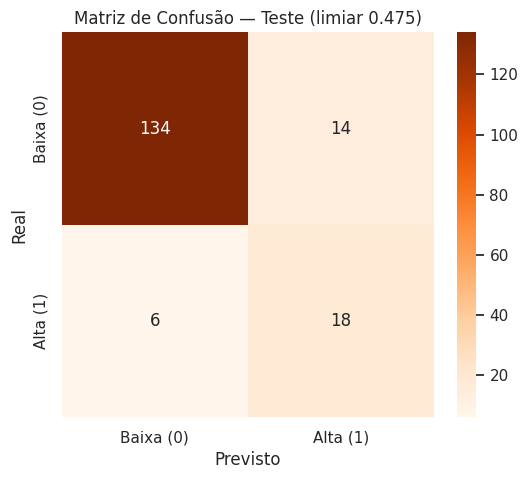

In [ ]:
y_pred_pot = (y_probs_rf >= limiar_pot).astype(int)

print(f"Relatório de Classificação — Teste (modelo: {melhor_modelo_nome}, limiar: {limiar_pot:.3f}):")
print(classification_report(y_test, y_pred_pot))

cm_pot = confusion_matrix(y_test, y_pred_pot)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_pot, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Baixa (0)', 'Alta (1)'], yticklabels=['Baixa (0)', 'Alta (1)'])
plt.xlabel('Previsto'); plt.ylabel('Real')
plt.title(f'Matriz de Confusão — Teste (limiar {limiar_pot:.3f})')
plt.show()

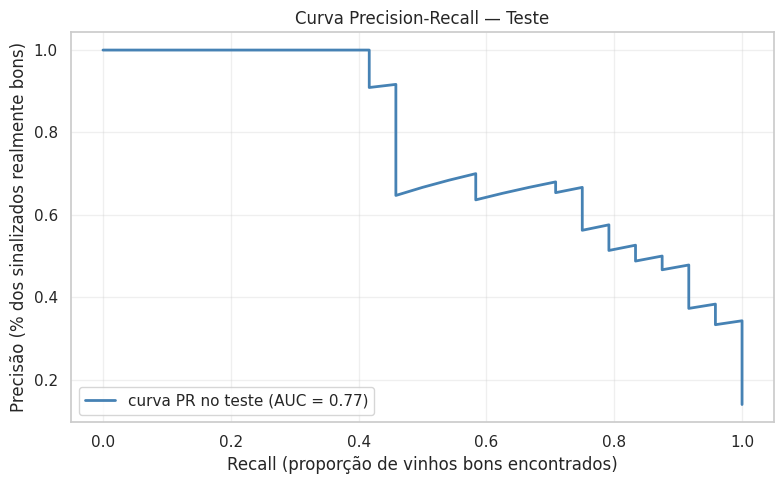

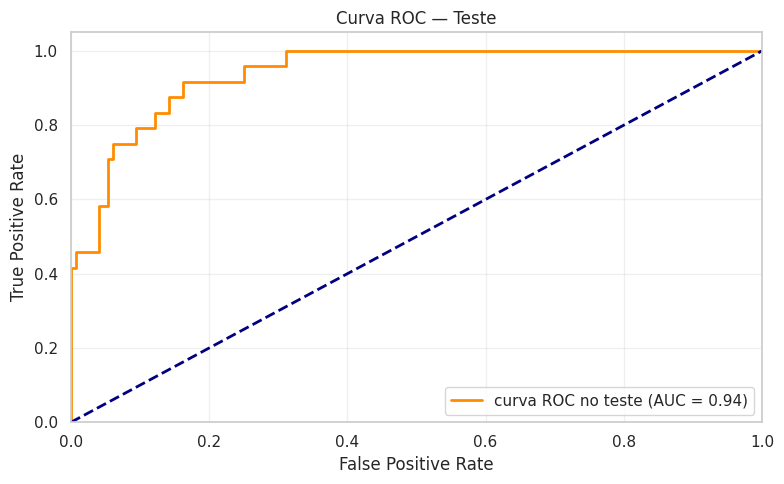

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

#plotar AUC-PR
plt.figure(figsize=(8, 5))
plt.plot(recall_test, precision_test, color='steelblue', lw=2,
         label=f'curva PR no teste (AUC = {auc_pr_test:.2f})')
plt.xlabel('Recall (proporção de vinhos bons encontrados)')
plt.ylabel('Precisão (% dos sinalizados realmente bons)')
plt.title('Curva Precision-Recall — Teste')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plotar Curva ROC
fpr_test, tpr_test, _ = roc_curve(y_test, y_probs_rf)
auc_roc_test = roc_auc_score(y_test, y_probs_rf)

plt.figure(figsize=(8, 5))
plt.plot(fpr_test, tpr_test, color='darkorange', lw=2,
         label=f'curva ROC no teste (AUC = {auc_roc_test:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC — Teste')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Interpretação dos Resultados

Quais variáveis mais influenciam a qualidade do
vinho, segundo o modelo, e o que isso sugere para o processo produtivo?

Importância das variáveis — modelo: RandomForest

alcool_por_densidade    0.145119
alcohol                 0.122980
citric acid             0.116033
volatile acidity        0.099658
sulphates               0.098150
acidez_total            0.058058
chlorides               0.056624
fixed acidity           0.053680
total sulfur dioxide    0.053427
density                 0.046920
razao_so2_livre         0.045855
pH                      0.037861
residual sugar          0.034098
free sulfur dioxide     0.031539
dtype: float64


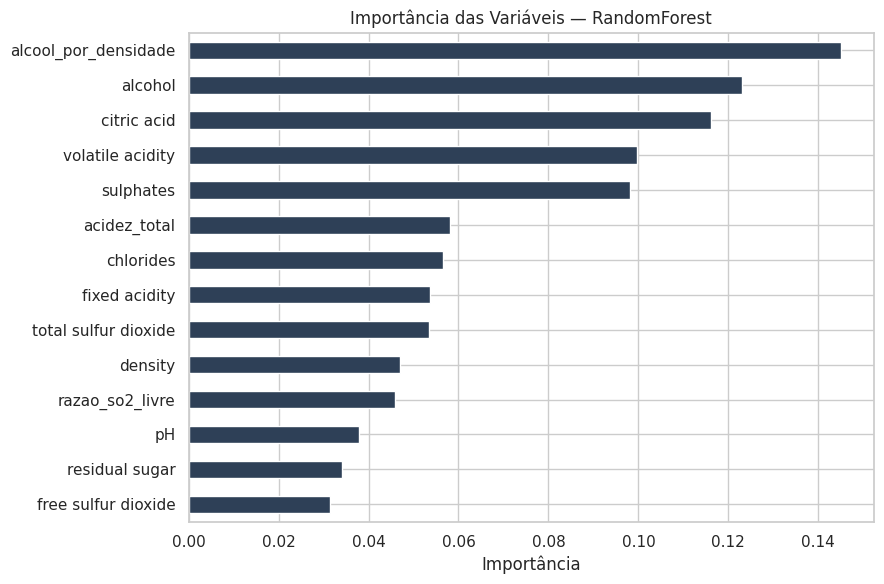

In [ ]:
def extrair_importancia(modelo, colunas):
    # Lida tanto com pipelines (ImbPipeline/Pipeline) quanto com o modelo puro
    modelo_interno = modelo.named_steps['modelo'] if hasattr(modelo, 'named_steps') else modelo
    if hasattr(modelo_interno, 'feature_importances_'):
        return pd.Series(modelo_interno.feature_importances_, index=colunas).sort_values(ascending=False)
    elif hasattr(modelo_interno, 'coef_'):
        return pd.Series(modelo_interno.coef_[0], index=colunas).sort_values(ascending=False)
    return None

importancias = extrair_importancia(modelo_final, X.columns)

print(f"Importância das variáveis — modelo: {melhor_modelo_nome}\n")
print(importancias)

plt.figure(figsize=(9, 6))
importancias.sort_values().plot(kind='barh', color='#2E4057')
plt.title(f'Importância das Variáveis — {melhor_modelo_nome}')
plt.xlabel('Importância' if hasattr(modelo_final, 'named_steps') and
           hasattr(modelo_final.named_steps.get('modelo'), 'feature_importances_')
           else 'Peso do coeficiente')
plt.tight_layout()
plt.show()


### Discussão

Implicações para o processo produtivo

Com base na importância das variáveis acima, alinhado ao que já tínhamos visto nas
correlações da seção 1.1, as implicações práticas para quem produz o vinho são:

- **Álcool** tende a ser a variável mais determinante. Como o teor alcoólico está diretamente
  ligado ao ponto de colheita da uva (nível de açúcar) e à condução da fermentação, o processo
  produtivo tem controle real sobre essa variável, é o ponto com maior elevação da
  qualidade prevista.
- **Acidez volátil** aparece como o segundo fator mais relevante, mas na direção inversa: reduzir
  a contaminação bacteriana durante a fermentação (controle de temperatura, higienização,
  monitoramento do processo) é uma ação de controle de qualidade.
- **Sulfatos e ácido cítrico** aparecem com importância moderada — ambos são aditivos/parâmetros
  que o enólogo ajusta diretamente (dosagem de sulfitos, correção de acidez), então são pontos de
  controle acionáveis no processo, não apenas variáveis de monitoramento passivo.
- **As variáveis criadas na seção 3** (`acidez_total`, `razao_so2_livre`, `alcool_por_densidade`)
  devem ser conferidas na lista acima: se aparecerem com importância baixa, isso sugere que a
  informação que elas carregam já estava capturada pelas variáveis originais — um resultado
  negativo também é um resultado válido para reportar.

**Limitação importante a declarar no relatório**: este modelo captura *associação*, não
*causalidade*. A importância de uma variável no modelo não prova que alterá-la isoladamente no
processo produtivo mudará a nota final. Outros fatores não capturados no dataset (uva, terroir,
clima da safra) também influenciam o resultado sensorial. O modelo é uma ferramenta de apoio à
decisão, não um substituto do enólogo.

## 12. Criação da demonstração de um instrumento para classificação humana pós triagem em camadas pelo modelo (Excel)

Mesma lógica de negócio da versão anterior (alta qualidade / potencialmente alta qualidade /
comum), mas agora usando os limiares calibrados na validação e aplicados uma única vez ao teste.

Distribuição das classificações:
classificacao
comum                            140
potencialmente alta qualidade     21
alta qualidade                    11
Name: count, dtype: int64

alta qualidade: 11 vinhos sinalizados -> 10 realmente bons (91%)
potencialmente alta qualidade: 21 vinhos sinalizados -> 8 realmente bons (38%)
comum: 140 vinhos sinalizados -> 134 realmente comuns (96%)


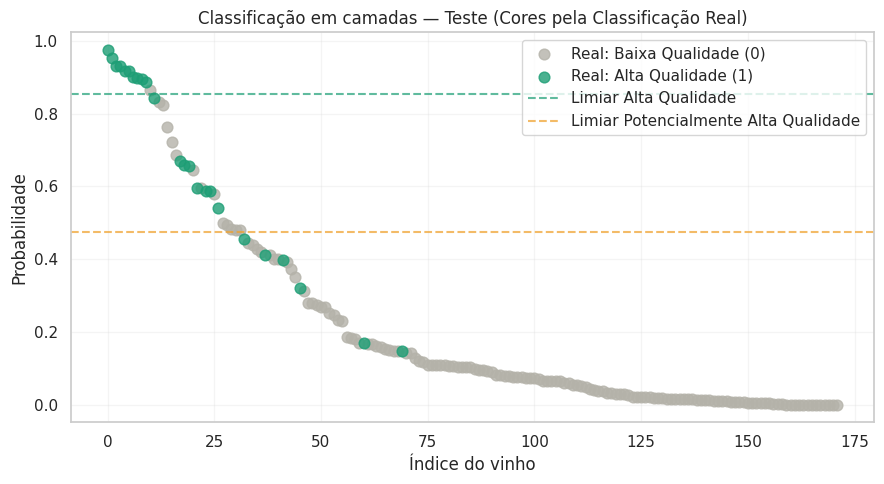

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,acidez_total,razao_so2_livre,alcool_por_densidade,probabilidade,classificacao,real
0,5.3,0.470,0.11,2.2,0.048,16.0,89.0,0.99182,3.54,0.88,13.6,5.770,0.179775,13.712166,0.975,alta qualidade,1
1,11.6,0.410,0.54,1.5,0.095,22.0,41.0,0.99735,3.02,0.76,9.9,12.010,0.536585,9.926305,0.952,alta qualidade,1
2,9.4,0.270,0.53,2.4,0.074,6.0,18.0,0.99620,3.20,1.13,12.0,9.670,0.333333,12.045774,0.931,alta qualidade,1
3,8.7,0.330,0.38,3.3,0.063,10.0,19.0,0.99468,3.30,0.73,12.0,9.030,0.526316,12.064181,0.930,alta qualidade,1
4,8.3,0.310,0.39,2.4,0.078,17.0,43.0,0.99444,3.31,0.77,12.5,8.610,0.395349,12.569889,0.917,alta qualidade,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167,7.6,0.430,0.29,2.1,0.075,19.0,66.0,0.99718,3.40,0.64,9.5,8.030,0.287879,9.526866,0.000,comum,0
168,7.4,0.640,0.07,1.8,0.100,8.0,23.0,0.99610,3.30,0.58,9.6,8.040,0.347826,9.637587,0.000,comum,0
169,7.8,0.600,0.26,2.0,0.080,31.0,131.0,0.99622,3.21,0.52,9.9,8.400,0.236641,9.937564,0.000,comum,0
170,7.9,1.040,0.05,2.2,0.084,13.0,29.0,0.99590,3.22,0.55,9.9,8.940,0.448276,9.940757,0.000,comum,0


In [ ]:
def classificar(p):
    if p >= limiar_alta:
        return 'alta qualidade'
    elif p >= limiar_pot:
        return 'potencialmente alta qualidade'
    else:
        return 'comum'

resultados = X_test.copy()
resultados['probabilidade'] = y_probs_rf.round(3)
resultados['classificacao'] = [classificar(p) for p in y_probs_rf]
resultados['real'] = y_test.values
resultados = resultados.sort_values('probabilidade', ascending=False).reset_index(drop=True)

print("Distribuição das classificações:")
print(resultados['classificacao'].value_counts())
print()

for categoria in ['alta qualidade', 'potencialmente alta qualidade']:
    subset = resultados[resultados['classificacao'] == categoria]
    acertos = (subset['real'] == 1).sum()
    total = len(subset)
    if total > 0:
        print(f"{categoria}: {total} vinhos sinalizados -> {acertos} realmente bons ({acertos/total*100:.0f}%)")

# Adicionando a porcentagem de acerto para a categoria 'comum'
subset_comum = resultados[resultados['classificacao'] == 'comum']
acertos_comum = (subset_comum['real'] == 0).sum()
total_comum = len(subset_comum)
if total_comum > 0:
    print(f"comum: {total_comum} vinhos sinalizados -> {acertos_comum} realmente comuns ({acertos_comum/total_comum*100:.0f}%)")

# Modificado para colorir pela classificação real
cores_reais = {
    0: '#B4B2A9', # Comum/Baixa Qualidade (Real)
    1: '#1D9E75'  # Alta Qualidade (Real)
}

nomes_reais = {
    0: 'Real: Baixa Qualidade (0)',
    1: 'Real: Alta Qualidade (1)'
}

plt.figure(figsize=(9, 5))
for real_class, cor in cores_reais.items():
    mask = resultados['real'] == real_class
    plt.scatter(resultados[mask].index, resultados[mask]['probabilidade'],
                color=cor, label=nomes_reais[real_class], alpha=0.8, s=60)
plt.axhline(limiar_alta, color='#1D9E75', lw=1.5, linestyle='--', alpha=0.7, label='Limiar Alta Qualidade')
plt.axhline(limiar_pot, color='#EF9F27', lw=1.5, linestyle='--', alpha=0.7, label='Limiar Potencialmente Alta Qualidade')
plt.xlabel('Índice do vinho')
plt.ylabel('Probabilidade')
plt.title('Classificação em camadas — Teste (Cores pela Classificação Real)')
plt.legend(loc='upper right') # Ajustar a posição da legenda para não sobrepor
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

resultados

In [ ]:
# Excel para triagem humana
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side

df_alta = resultados[resultados['classificacao'] == 'alta qualidade']
df_pot  = resultados[resultados['classificacao'] == 'potencialmente alta qualidade']
df_com  = resultados[resultados['classificacao'] == 'comum']

VERDE_FILL   = PatternFill('solid', start_color='C6EFCE')
VERDE_FONT   = Font(color='276221', name='Arial', size=10)
LARANJA_FILL = PatternFill('solid', start_color='FFDFA0')
LARANJA_FONT = Font(color='7B4F00', name='Arial', size=10)
CINZA_FILL   = PatternFill('solid', start_color='F1F1F1')
CINZA_FONT   = Font(color='555555', name='Arial', size=10)
HEADER_FILL  = PatternFill('solid', start_color='2E4057')
HEADER_FONT  = Font(color='FFFFFF', bold=True, name='Arial', size=10)
thin   = Side(style='thin', color='CCCCCC')
border = Border(left=thin, right=thin, top=thin, bottom=thin)

cols = list(resultados.columns)

def escrever_aba(ws, df_aba, fill, font):
    for c, col in enumerate(cols, 1):
        cell = ws.cell(row=1, column=c, value=col)
        cell.font = HEADER_FONT
        cell.fill = HEADER_FILL
        cell.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
        cell.border = border
    ws.row_dimensions[1].height = 30
    for r, (_, row) in enumerate(df_aba.iterrows(), 2):
        for c, col in enumerate(cols, 1):
            cell = ws.cell(row=r, column=c, value=row[col])
            cell.font = font
            cell.fill = fill
            cell.border = border
    for c, col in enumerate(cols, 1):
        ws.column_dimensions[chr(64 + c) if c <= 26 else 'A'].width = max(12, len(str(col)) + 2)

wb = Workbook()
wb.remove(wb.active)

ws_alta = wb.create_sheet('Alta Qualidade')
escrever_aba(ws_alta, df_alta, VERDE_FILL, VERDE_FONT)

ws_pot = wb.create_sheet('Potencialmente Alta')
escrever_aba(ws_pot, df_pot, LARANJA_FILL, LARANJA_FONT)

ws_com = wb.create_sheet('Comum')
escrever_aba(ws_com, df_com, CINZA_FILL, CINZA_FONT)

wb.save('classificacao_vinhos_teste.xlsx')
print("Arquivo 'classificacao_vinhos_teste.xlsx' salvo com sucesso.")


Arquivo 'classificacao_vinhos_teste.xlsx' salvo com sucesso.
